<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 6 — Perceptrón, MLP, Backpropagation y Métricas Clínicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

En el Challenge 5 trabajaste con el dataset **Breast Cancer Wisconsin** como problema no supervisado: aplicaste PCA, K-means y DBSCAN sin usar las etiquetas durante el entrenamiento.

Ahora usaremos el **mismo contexto biomédico**, pero como problema supervisado de clasificación binaria. Cada muestra corresponde a características morfológicas calculadas a partir de imágenes digitalizadas de aspirado con aguja fina (FNA) de masa mamaria. El objetivo será entrenar modelos neuronales en **PyTorch** para clasificar si una muestra corresponde a un tumor **maligno** o **benigno**.

**Pregunta clínica:** ¿puede una red neuronal simple mejorar la clasificación diagnóstica frente a un perceptrón/modelo lineal? ¿Qué métrica debería priorizarse si el error más crítico es no detectar un tumor maligno?

---
> **Fuente:** Wolberg, W. H. et al. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI ML Repository.  
> Disponible directamente en `sklearn.datasets.load_breast_cancer()` — no requiere descarga.

### Estructura de carpetas
```text
Clase10_Challenge6/
└── Challenge6_ApellidoNombre.ipynb    ← no se necesita CSV externo
```

**Nota importante:** en `sklearn`, la etiqueta original es `0 = malignant` y `1 = benign`. En este challenge invertiremos la codificación para trabajar clínicamente con:

```text
0 = benigno
1 = maligno  ← clase positiva clínica
```


---
## Ejercicio 1 — Diseño previo al código

### 1.1 — Neurona artificial, perceptrón y MLP

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

**1.** Completa la expresión general de una neurona artificial:

$$z = \mathbf{w}^T\mathbf{x} + b \qquad ; \qquad a = \phi(z)$$

¿Qué representan $\mathbf{x}$, $\mathbf{w}$, $b$ y $\phi$ en este problema biomédico?

**📝 Tu respuesta:**  
$\mathbf{x}$: Representa las características morfológicas cuantitativas extraídas del procesamiento digital de las imágenes de las células  
$\mathbf{w}$: Representa el peso asignado a las características morfológicas  
$b$: Es el umbral del modelo hacia una de las clases  
$\phi$:Es la función matemática que introduce no linealidad y mapea el valor de $z$ a un rango interpretable


---

**2.** Explica la diferencia entre un perceptrón/modelo lineal y un MLP.

| Modelo | ¿Qué aprende? | Tipo de frontera de decisión |
|---|---|---|
| Perceptrón / modelo lineal | Aprende una única combinación lineal | Lineal |
| MLP | Aprende representaciones jerárquicas y abstractas de los datos | No lineal |

---

**3.** ¿Por qué una salida de una sola neurona puede ser suficiente para clasificación binaria?

**📝 Tu respuesta:**  
Una sola neurona de salida configurada con una función de activación Sigmoide mapeará cualquier valor real a un rango continuo entre 0 y 1. Este valor se interpreta estadísticamente como la probabilidad de pertenecer a la clase positiva. Estableciendo un umbral de decisión, una sola salida permite la decisión clínica: si la salida es mayor o igual al umbral se clasifica como maligno, y si es menor, como benigno.

---

**4.** En clasificación benigno/maligno, ¿qué error clínico es más grave: falso positivo o falso negativo? ¿Por qué?

**📝 Tu respuesta:**  
En el diagnóstico de cáncer de mama, un falso negativo es considerablemente más grave. Un falso negativo resulta en dar de alta a un paciente que en realidad tiene cáncer. El paciente no recibirá tratamiento temprano, lo que ocasiona que la enfermedad progrese, haga metástasis y se reduzca drásticamente la tasa de supervivencia. Es un error que pone en riesgo inminente la vida del paciente.


### 1.2 — Backpropagation y función de pérdida

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Para clasificación binaria usaremos una pérdida tipo Binary Cross-Entropy.

**1.** Completa:

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(p) + (1-y_i)\log(1-p)\right]$$

---

**2.** Ordena los pasos de entrenamiento en PyTorch:

| Paso | Código PyTorch | ¿Qué hace? |
|---|---|---|
| 1 | `logits = model(X_batch)` | Pasa el lote de características morfológicas a través de la red |
| 2 | `loss = loss_fn(logits, y_batch)` | Cuantifica la diferencia entre las predicciones de la red y las etiquetas reales |
| 3 | `optimizer.zero_grad()` | Limpia los gradientes calculados en la iteración anterior |
| 4 | `loss.backward()` | Recorre el grafo computacional hacia atrás calculando las derivadas parciales de la pérdida respecto a cada peso y sesgo |
| 5 | `optimizer.step()` | Ajusta los valores de los parámetros del modelo en la dirección opuesta al gradiente |

---

**3.** ¿Por qué en PyTorch primero calculamos la pérdida y recién después llamamos a `loss.backward()`?

**📝 Tu respuesta:**  
Porque al calcular la pérdida, PyTorch construye en memoria el grafo computacional. El comando loss.backward() necesita que este grafo ya exista para poder recorrerlo en reversa y aplicar la regla de la cadena para calcular los gradientes.


### 1.3 — Pipeline completo

Completa el siguiente pipeline:

```text
load_breast_cancer()
        │
        ▼
[ Paso A ] Extracción de características (X) y etiquetas (y)
        │
        ▼
[ Paso B ] Split estratificado: train_test_split(X, y, test_size=0.2, stratify=y)
        │
        ▼
[ Paso C ] StandardScaler
           fit en X_train ; transform en X_train y X_test
        │
        ▼
[ Paso D ] Conversión a torch.Tensor
           X: torch.float32 ; y: torch.float32 con shape (N, 1)
        │
        ▼
[ Paso E ] Creación de batches (TensorDataset y DataLoader)
        │
        ├──── Modelo 1: Perceptrón / Modelo Lineal (capa única)
        │
        └──── Modelo 2: MLP (Perceptrón Multicapa con capas ocultas)
        │
        ▼
[ Paso F ] Entrenamiento explícito:
           forward → loss (BCE) → zero_grad → backward() → step
        │
        ▼
[ Paso G ] Evaluación clínica:
           matriz de confusión, accuracy, sensibilidad,
           especificidad, precisión, F1, Curva ROC y AUC
```

**📝 Tu respuesta:** completa los blancos arriba.


---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 2.1 — Librerías

In [1]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TODO 1: importa PyTorch y sus módulos principales
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer

# TODO 2: importa train_test_split, StandardScaler y métricas clínicas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

plt.rcParams['figure.dpi'] = 120

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# TODO 3: selecciona GPU si está disponible; si no, CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup completo ✓ | device = {device}')

Setup completo ✓ | device = cpu


### Paso 2.2 — Carga del dataset y recodificación clínica

In [2]:
# ── Carga del dataset ──────────────────────────────────────────
data = load_breast_cancer()
X = data.data.astype(np.float32)
feature_names = data.feature_names

# sklearn: 0 = malignant, 1 = benign
# challenge: 0 = benigno, 1 = maligno (clase positiva clínica)
# TODO 4: invierte la etiqueta original para que 1 sea maligno
y = 1 - data.target

label_map = {0: 'Benigno', 1: 'Maligno'}
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y

print(f'Shape X: {X.shape}')
print(f'Número de features: {X.shape[1]}')
print('Codificación usada en este challenge: 0=Benigno, 1=Maligno')
print('\nDistribución de clases:')
print(df['diagnosis'].map(label_map).value_counts())
df.head()

Shape X: (569, 30)
Número de features: 30
Codificación usada en este challenge: 0=Benigno, 1=Maligno

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.330000,184.600006,2019.000000,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.410000,158.800003,1956.000000,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.530001,152.500000,1709.000000,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.500000,98.870003,567.700012,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.670000,152.199997,1575.000000,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### Paso 2.3 — EDA inicial

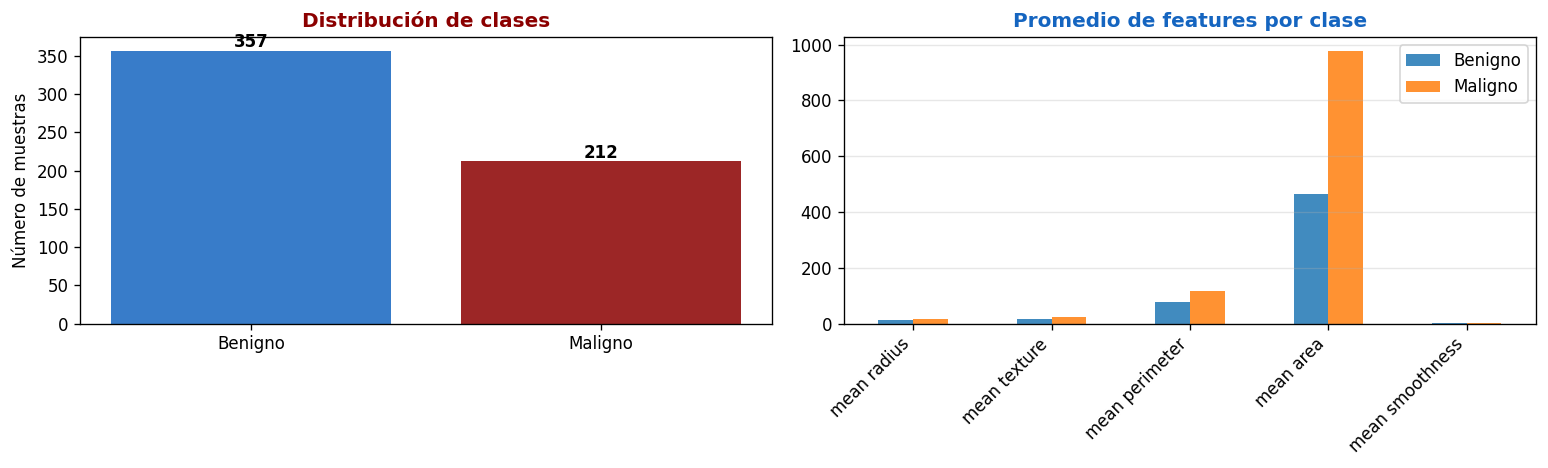

Resumen estadístico de las primeras 5 variables:


mean radius                                                  \
                count   mean   std    min    25%    50%    75%    max   
diagnosis                                                               
0               357.0  12.15  1.78   6.98  11.08  12.20  13.37  17.85   
1               212.0  17.46  3.20  10.95  15.08  17.32  19.59  28.11   

          mean texture         ... mean area         mean smoothness        \
                 count   mean  ...       75%     max           count  mean   
diagnosis                      ...                                           
0                357.0  17.91  ...    551.10   992.1           357.0  0.09   
1                212.0  21.60  ...   1203.75  2501.0           212.0  0.10   

                                               
            std   min   25%   50%   75%   max  
diagnosis                                      
0          0.01  0.05  0.08  0.09  0.10  0.16  
1          0.01  0.07  0.09  0.10  0.11  0.14  

[2 rows x 40 columns]

In [3]:
# ── Distribución de clases y resumen de features ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['diagnosis'].map(label_map).value_counts()
axes[0].bar(counts.index, counts.values, color=[UPCH_BLUE, UPCH_RED], alpha=0.85)
axes[0].set_title('Distribución de clases', fontsize=12, fontweight='bold', color=UPCH_RED)
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df.groupby('diagnosis')[selected_features].mean().T.plot(kind='bar', ax=axes[1], alpha=0.85)
axes[1].set_title('Promedio de features por clase', fontsize=12, fontweight='bold', color=UPCH_BLUE)
axes[1].set_xticklabels(selected_features, rotation=45, ha='right')
axes[1].legend(['Benigno', 'Maligno'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('challenge6_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen estadístico de las primeras 5 variables:')
df[selected_features + ['diagnosis']].groupby('diagnosis').describe().round(2)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

**1. ¿El dataset está balanceado o desbalanceado?**  
Está moderadamente desbalanceado. Hay una clara mayoría de muestras benignas (357) frente a las malignas (212), lo que representa aproximadamente una relación de 63% a 37%.

**2. ¿Qué diferencias observas entre benigno y maligno en las variables exploradas?**  
En promedio, las masas malignas presentan valores consistentemente mayores en todas las métricas morfológicas analizadas (radio, textura, perímetro, área y suavidad). Esto indica clínicamente que las células tumorales tienden a ser más grandes, de bordes más irregulares y con mayor textura que las benignas.

**3. ¿Qué métrica clínica deberíamos cuidar más si nos preocupa no perder casos malignos?**  
El recall, el cual es una métrica vital porque penaliza fuertemente los falsos negativos, asegurando que no perdamos pacientes que requieren tratamiento oncológico urgente.

**4. ¿Por qué será necesario escalar las variables antes de entrenar una red neuronal?**  
Por la extrema diferencia de magnitudes entre las características. En la tabla se observa que el mean area maneja valores superiores a 1000, mientras que el mean smoothness está en el orden de 0.1. Sin escalado, las variables de mayor magnitud dominarán la actualización de los pesos durante el entrenamiento, generando gradientes inestables y un sesgo matemático en la red.


---
# PARTE 1 — De datos tabulares a tensores PyTorch
## Ejercicio 3 — Split, escalado y DataLoader

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 3.1 — Train / validation / test split

In [4]:
# ── Split estratificado ─────────────────────────────────────────
# TODO 5: separa primero test = 20% manteniendo proporción de clases
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# TODO 6: separa validation a partir de trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f'Train:      {X_train.shape} | malignos={y_train.sum()}')
print(f'Validation: {X_val.shape} | malignos={y_val.sum()}')
print(f'Test:       {X_test.shape} | malignos={y_test.sum()}')

Train:      (341, 30) | malignos=127
Validation: (114, 30) | malignos=43
Test:       (114, 30) | malignos=42


### Paso 3.2 — Escalado sin data leakage

In [5]:
# ── StandardScaler: fit SOLO en train ───────────────────────────
scaler = StandardScaler()

# TODO 7: ajusta el scaler solo en train y transforma train/val/test
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Media aproximada train escalado:', X_train_sc.mean(axis=0)[:3].round(4))
print('Desv. estándar train escalado:', X_train_sc.std(axis=0)[:3].round(4))

Media aproximada train escalado: [ 0.  0. -0.]
Desv. estándar train escalado: [1. 1. 1.]


### Paso 3.3 — Conversión a tensores y creación de DataLoaders

In [6]:
# ── Conversión a tensores ───────────────────────────────────────
# TODO 8: convierte X a tensores float32
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_sc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_sc, dtype=torch.float32)

# TODO 9: convierte y a tensores float32 con shape (N, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

BATCH_SIZE = 32

# TODO 10: crea TensorDataset y DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'X_train_t: {X_train_t.shape} | y_train_t: {y_train_t.shape}')
print(f'Número de mini-batches train: {len(train_loader)}')

X_train_t: torch.Size([341, 30]) | y_train_t: torch.Size([341, 1])
Número de mini-batches train: 11


### Paso 3.4 — Inspección de un mini-batch

In [7]:
# ── Inspección de mini-batch ────────────────────────────────────
X_batch, y_batch = next(iter(train_loader))
print(f'X_batch shape: {X_batch.shape}')
print(f'y_batch shape: {y_batch.shape}')
print(f'Primeras etiquetas del batch: {y_batch[:8].view(-1).numpy().astype(int)}')
print('\nInterpretación: cada fila tiene 30 features; cada etiqueta tiene shape (1, ) para BCEWithLogitsLoss.')

X_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 1])
Primeras etiquetas del batch: [0 1 0 1 0 0 0 1]

Interpretación: cada fila tiene 30 features; cada etiqueta tiene shape (1, ) para BCEWithLogitsLoss.


### Paso 3.5 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Qué representa la dimensión 30 en `X_batch`?**  
Representa las 30 características morfológicas cuantitativas extraídas de las imágenes FNA para cada muestra.

**2. ¿Por qué `y_batch` tiene shape `(batch_size, 1)`?**  
Porque la red utiliza una sola neurona de salida para esta clasificación binaria. En PyTorch, funciones de pérdida como BCEWithLogitsLoss exigen que el tensor de etiquetas reales (y_batch) tenga exactamente las mismas dimensiones anatómicas que el tensor de predicciones del modelo (que será [32, 1]).

**3. ¿Por qué usamos `shuffle=True` en train y `shuffle=False` en validation/test?**  
Por un lado, en train (shuffle=True): Garantiza que cada lote sea aleatorio, evitando que la red memorice el orden de los datos o se estanque en mínimos locales sesgados por secuencias de una misma clase.

Por otro lado, en val/test (shuffle=False): No es necesario aleatorizar porque aquí no actualizamos pesos (no hay aprendizaje). Mantener el orden fijo es más eficiente y facilita rastrear clínicamente qué muestras específicas fallaron al depurar.

**4. ¿Para qué nos sirve separar validation y test?**  
Validation: Sirve para detectar el sobreajuste (overfitting) a tiempo y ajustar hiperparámetros (arquitectura de la red, learning rate) sin contaminar la evaluación final.

Test: Es la simulación clínica final. Son datos que el modelo jamás ha visto durante el ciclo de desarrollo, lo que te permite reportar la verdadera capacidad de generalización del algoritmo antes de llevarlo a producción.


---
# PARTE 2 — Perceptrón / Clasificador Lineal en PyTorch
## Ejercicio 4 — Modelo lineal, entrenamiento y backpropagation

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 4.1 — Definición del modelo lineal

In [8]:
# ── Perceptrón / modelo lineal para clasificación binaria ──────
class LogisticPerceptron(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # TODO 11: una capa lineal que reciba n_features y devuelva 1 logit
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        # TODO 12: calcula el logit
        logits = self.linear(x)
        return logits

n_features = X_train_t.shape[1]
perceptron = LogisticPerceptron(n_features).to(device)
print(perceptron)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in perceptron.parameters())}')

LogisticPerceptron(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)
Número de parámetros entrenables: 31


### Paso 4.2 — Funciones de entrenamiento y evaluación

In [9]:
# ── Funciones reutilizables de entrenamiento ───────────────────
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # TODO 13: completa el flujo forward → loss → zero_grad → backward → step
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=100, device=device):
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss   = evaluate_loss(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch == 1 or epoch % 25 == 0:
            print(f'Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

    return history

### Paso 4.3 — Entrenamiento del perceptrón

In [10]:
# ── Entrenamiento del modelo lineal ─────────────────────────────
seed_everything(42)
perceptron = LogisticPerceptron(n_features).to(device)

# TODO 14: define la pérdida y el optimizador
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(perceptron.parameters(), lr=0.001)

hist_perc = train_model(perceptron, train_loader, val_loader,
                        loss_fn, optimizer, epochs=100, device=device)

Epoch 001 | train_loss=0.6266 | val_loss=0.6381
Epoch 025 | train_loss=0.1984 | val_loss=0.2206
Epoch 050 | train_loss=0.1322 | val_loss=0.1420
Epoch 075 | train_loss=0.1067 | val_loss=0.1130
Epoch 100 | train_loss=0.0931 | val_loss=0.0983


### Paso 4.4 — Curvas de pérdida

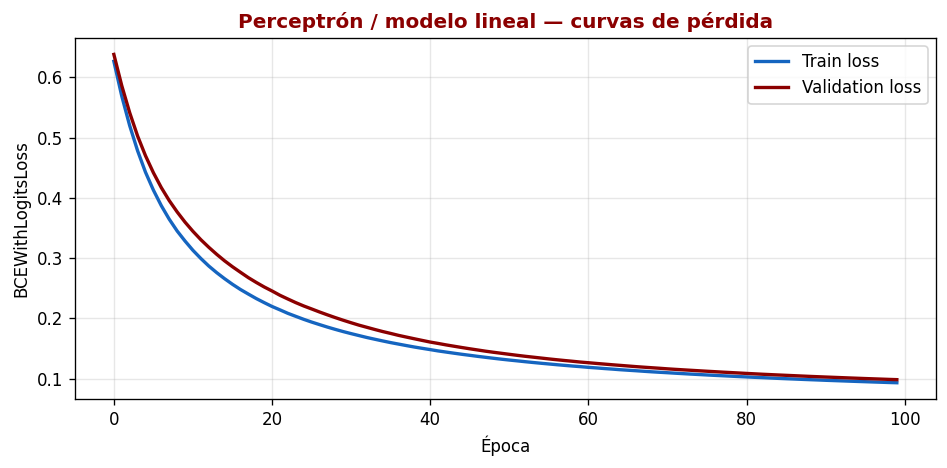

In [11]:
# ── Curvas de pérdida ───────────────────────────────────────────
def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['train_loss'], label='Train loss', color=UPCH_BLUE, lw=2)
    ax.plot(history['val_loss'], label='Validation loss', color=UPCH_RED, lw=2)
    ax.set_xlabel('Época')
    ax.set_ylabel('BCEWithLogitsLoss')
    ax.set_title(title, fontsize=12, fontweight='bold', color=UPCH_RED)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(hist_perc, 'Perceptrón / modelo lineal — curvas de pérdida')

### Paso 4.5 — Funciones de predicción y métricas clínicas

In [12]:
# ── Predicción y métricas clínicas ──────────────────────────────
@torch.no_grad()
def predict_proba(model, X_tensor, device):
    model.eval()
    logits = model(X_tensor.to(device))
    # TODO 15: convierte logits a probabilidades con sigmoid
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    return probs


def clinical_metrics(y_true, y_prob, threshold=0.5):
    # TODO 16: convierte probabilidades a clases usando threshold
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity_recall_malignant': recall_score(y_true, y_pred, pos_label=1),
        'specificity_benign': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'precision_malignant': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_malignant': f1_score(y_true, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_confusion(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Reds')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_yticklabels(['Benigno', 'Maligno'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(title, fontsize=11, fontweight='bold', color=UPCH_RED)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

### Paso 4.6 — Evaluación del perceptrón

In [13]:
# ── Evaluación del perceptrón en test ───────────────────────────
y_prob_perc = predict_proba(perceptron, X_test_t, device)
metrics_perc = clinical_metrics(y_test, y_prob_perc, threshold=0.5)

pd.DataFrame([metrics_perc]).T.rename(columns={0: 'Perceptrón'}).round(4)

,Perceptrón
threshold,0.5000
accuracy,0.9737
sensitivity_recall_malignant,0.9524
specificity_benign,0.9861
precision_malignant,0.9756
f1_malignant,0.9639
roc_auc,0.9977
tn,71.0000
fp,1.0000
fn,2.0000


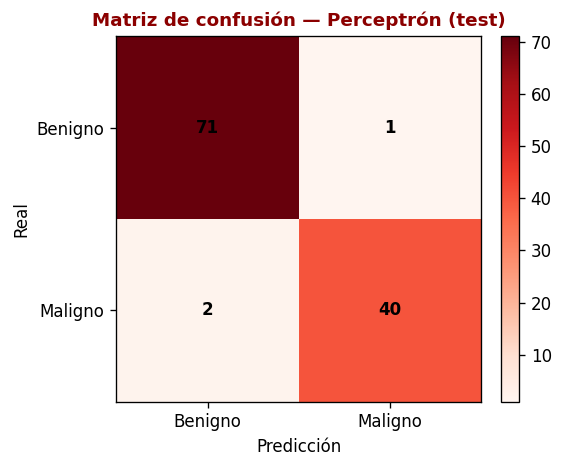

In [14]:
plot_confusion(y_test, y_prob_perc,
               title='Matriz de confusión — Perceptrón (test)',
               threshold=0.5)

### Paso 4.7 — Interpretación del perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿La pérdida de train y validation disminuye de forma coherente?**  
Sí, disminuye de forma excelente y coherente. Observando la gráfica, ambas curvas caen de manera suave y convergen juntas hacia un valor de pérdida mínimo (cerca de 0.1) a lo largo de las 100 épocas. La curva de validación sigue muy de cerca a la de entrenamiento en todo momento, sin divergir ni rebotar hacia arriba.

**2. ¿El perceptrón parece suficiente para este problema? Justifica con métricas.**  
Sí, parece altamente capaz. Las métricas calculadas a partir de la matriz son excelentes para un modelo lineal simple.

**3. ¿Cuántos falsos negativos obtuvo el modelo? ¿Por qué son clínicamente importantes?**  
Obtuvo 2 falsos negativos. Son la métrica más crítica en oncología, ya que representan a pacientes con cáncer activo que serían dados de alta sin recibir atención médica urgente, arriesgando su supervivencia.

**4. Si se quisiera aumentar la sensibilidad para malignidad, ¿qué podríamos modificar en la etapa de decisión?**  
Se debe reducir el umbral de decisión (threshold) de la función de activación final durante la etapa de inferencia. En lugar de usar el corte estadístico estándar de 0.5, se puede usar un valor menor (por ejemplo, 0.3 o 0.4). Esto hará que el modelo clasifique una muestra como maligna ante un menor nivel de probabilidad matemática, eliminando esos falsos negativos a cambio de aceptar algunos falsos positivos adicionales.


---
# PARTE 3 — Multi-Layer Perceptron y Backpropagation
## Ejercicio 5 — MLP para clasificación diagnóstica

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 5.1 — Definición del MLP

In [15]:
# ── MLP simple para datos tabulares ─────────────────────────────
class MLPClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

seed_everything(42)
mlp = MLPClassifier(n_features).to(device)
print(mlp)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in mlp.parameters())}')

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
Número de parámetros entrenables: 641


### Paso 5.2 — Entrenamiento del MLP

In [16]:
# ── Entrenamiento del MLP ───────────────────────────────────────
# TODO 17: define pérdida y optimizador para el MLP
loss_fn_mlp = nn.BCEWithLogitsLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.0005, weight_decay=1e-4)

hist_mlp = train_model(mlp, train_loader, val_loader,
                       loss_fn_mlp, optimizer_mlp, epochs=150, device=device)

Epoch 001 | train_loss=0.6937 | val_loss=0.6883
Epoch 025 | train_loss=0.2183 | val_loss=0.2306
Epoch 050 | train_loss=0.0873 | val_loss=0.0925
Epoch 075 | train_loss=0.0582 | val_loss=0.0678
Epoch 100 | train_loss=0.0435 | val_loss=0.0655
Epoch 125 | train_loss=0.0324 | val_loss=0.0667
Epoch 150 | train_loss=0.0244 | val_loss=0.0684


### Paso 5.3 — Comparación de curvas de pérdida

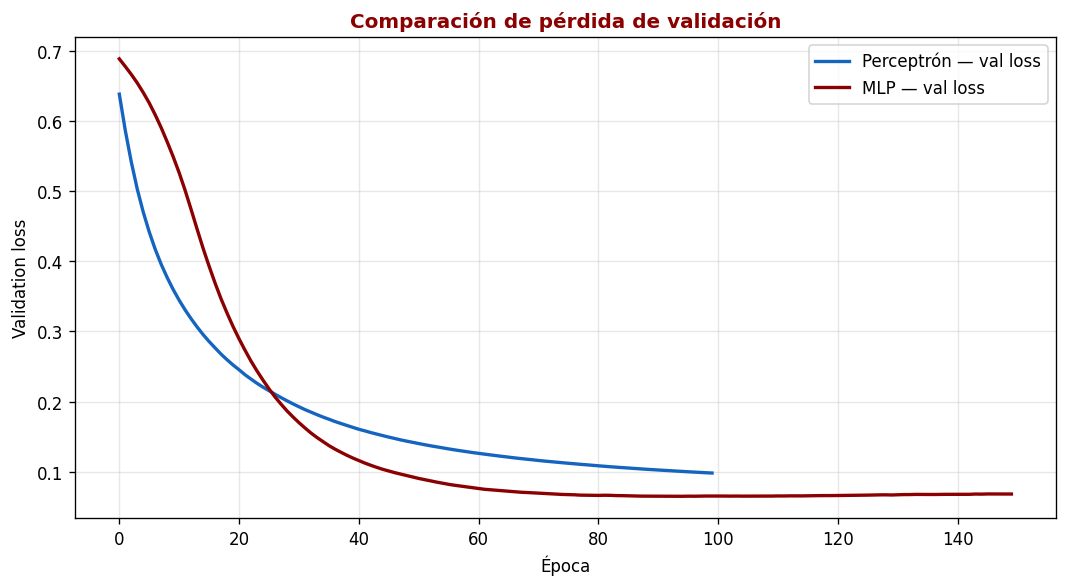

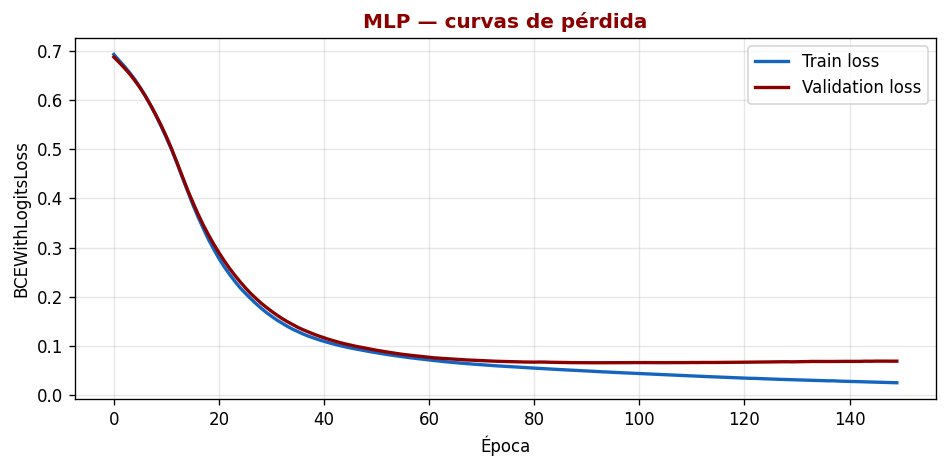

In [17]:
# ── Comparación de curvas ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_perc['val_loss'], label='Perceptrón — val loss', color=UPCH_BLUE, lw=2)
ax.plot(hist_mlp['val_loss'], label='MLP — val loss', color=UPCH_RED, lw=2)
ax.set_xlabel('Época')
ax.set_ylabel('Validation loss')
ax.set_title('Comparación de pérdida de validación', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plot_history(hist_mlp, 'MLP — curvas de pérdida')

### Paso 5.4 — Evaluación del MLP

In [18]:
# ── Evaluación del MLP en test ─────────────────────────────────
# TODO 18: predice probabilidades del MLP y calcula métricas clínicas
y_prob_mlp = predict_proba(mlp, X_test_t, device)
metrics_mlp = clinical_metrics(y_test, y_prob_mlp, threshold = 0.5)

comparison = pd.DataFrame([metrics_perc, metrics_mlp], index=['Perceptrón', 'MLP'])
comparison[['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
            'precision_malignant', 'f1_malignant', 'roc_auc', 'fn', 'fp']].round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,fn,fp
Perceptrón,0.9737,0.9524,0.9861,0.9756,0.9639,0.9977,2,1
MLP,0.9649,0.9286,0.9861,0.9750,0.9512,0.9944,3,1


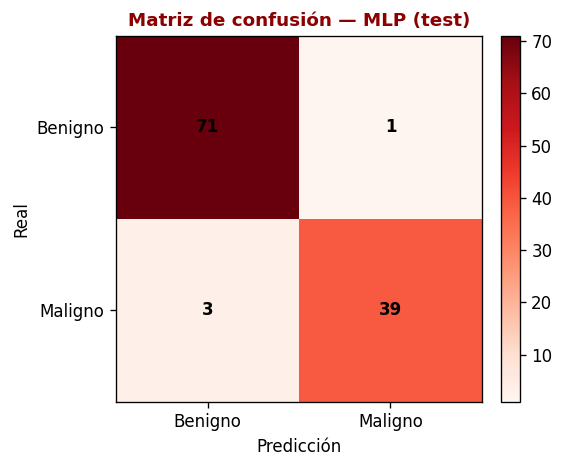

In [19]:
plot_confusion(y_test, y_prob_mlp,
               title='Matriz de confusión — MLP (test)',
               threshold=0.5)

### Paso 5.5 — Interpretación MLP vs perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿El MLP mejora al perceptrón en validation loss o en métricas de test?**  
No, de hecho, empeora. En las métricas de test, el MLP muestra un rendimiento inferior: su exactitud global cae de 0.97 a 0.96 y, lo más crítico, su sensibilidad para detectar malignidad se reduce de 0.95 a 0.93.

**2. ¿Hay señales de overfitting? Justifica usando las curvas de pérdida.**  
Sí, es altamente probable. Aunque no adjuntaste la gráfica de épocas del MLP en esta interacción, la degradación de las métricas de test al introducir más parámetros es un síntoma claro.

**3. ¿Qué modelo elegirías para este problema si priorizas sensibilidad para malignidad?**  
Elegiría el Perceptrón. Al priorizar la sensibilidad oncológica, el perceptrón es superior porque arrojó solo 2 falsos negativos (95.24% de sensibilidad), frente a los 3 falsos negativos del MLP (92.86% de sensibilidad).

**4. ¿Por qué un modelo más complejo no siempre es clínicamente mejor?**  
Si las características morfológicas del tumor ya son linealmente separables (como demostró el éxito del perceptrón), un modelo más denso e interconectado como el MLP utilizará esa capacidad adicional no para aprender patrones subyacentes reales, sino para sobreajustarse a las peculiaridades y ruidos específicos de la muestra de entrenamiento.


---
# PARTE 4 — Métricas Clínicas y Umbral de Decisión
## Ejercicio 6 — Evaluación final y análisis clínico

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 6.1 — Análisis de umbrales

In [20]:
# ── Sensibilidad al umbral de decisión ──────────────────────────
# TODO 19: prueba al menos 5 umbrales
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for thr in thresholds:
    m = clinical_metrics(y_test, y_prob_mlp, threshold=thr)
    rows.append({
        'threshold': thr,
        'accuracy': m['accuracy'],
        'sensitivity_malignant': m['sensitivity_recall_malignant'],
        'specificity_benign': m['specificity_benign'],
        'precision_malignant': m['precision_malignant'],
        'f1_malignant': m['f1_malignant'],
        'FN': m['fn'],
        'FP': m['fp']
    })

df_thr = pd.DataFrame(rows)
df_thr.round(4)

,threshold,accuracy,sensitivity_malignant,specificity_benign,precision_malignant,f1_malignant,FN,FP
0,0.1,0.9386,0.9762,0.9167,0.8723,0.9213,1,6
1,0.3,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
2,0.5,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
3,0.7,0.9737,0.9286,1.0000,1.0000,0.9630,3,0
4,0.9,0.9649,0.9048,1.0000,1.0000,0.9500,4,0


### Paso 6.2 — Curva ROC

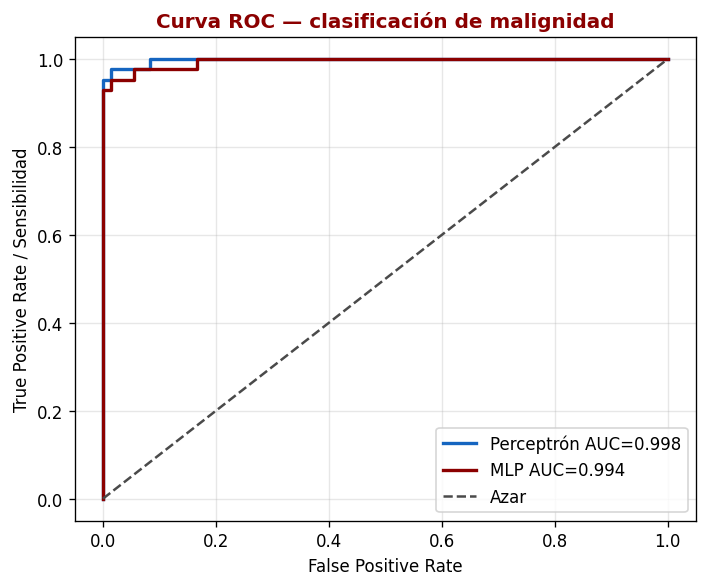

In [21]:
# ── Curva ROC ───────────────────────────────────────────────────
# TODO 20: calcula ROC y AUC para ambos modelos
fpr_perc, tpr_perc, _ = roc_curve(y_test, y_prob_perc)
fpr_mlp, tpr_mlp,  _ = roc_curve(y_test, y_prob_mlp)
auc_perc = roc_auc_score(y_test, y_prob_perc)
auc_mlp  = roc_auc_score(y_test, y_prob_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_perc, tpr_perc, color=UPCH_BLUE, lw=2, label=f'Perceptrón AUC={auc_perc:.3f}')
ax.plot(fpr_mlp, tpr_mlp, color=UPCH_RED, lw=2, label=f'MLP AUC={auc_mlp:.3f}')
ax.plot([0, 1], [0, 1], '--', color=UPCH_GRAY, label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate / Sensibilidad')
ax.set_title('Curva ROC — clasificación de malignidad', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 6.3 — Tabla final comparativa

In [22]:
# ── Tabla final comparativa ────────────────────────────────────
final_cols = ['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
              'precision_malignant', 'f1_malignant', 'roc_auc', 'tn', 'fp', 'fn', 'tp']

final_table = comparison[final_cols].copy()
final_table.index.name = 'Modelo'
final_table.round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,tn,fp,fn,tp
Modelo,,,,,,,,,,
Perceptrón,0.9737,0.9524,0.9861,0.9756,0.9639,0.9977,71,1,2,40
MLP,0.9649,0.9286,0.9861,0.9750,0.9512,0.9944,71,1,3,39


### Paso 6.4 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

**1. Tabla resumen — completa con los valores obtenidos:**

| Modelo | Accuracy | Sensibilidad maligno | Especificidad benigno | F1 maligno | ROC-AUC | FN | FP |
|---|---:|---:|---:|---:|---:|---:|---:|
| Perceptrón | 0.97 | 0.95 | 0.99 | 0.96 | 0.99 | 2 | 1 | 
| MLP | 0.96 | 0.93 | 0.99 | 0.95 | 0.99 | 3 | 1 | 

---

**2. ¿Cuál modelo elegirías para este problema diagnóstico y por qué?**  
El Perceptrón, debido a que supera al MLP en la métrica oncológica más crítica: la sensibilidad (0.9524 frente a 0.9286), logrando reducir los Falsos Negativos. Además, al ser un modelo más simple, es menos propenso a sobreajustarse a la varianza de los datos de entrenamiento.

**3. ¿Qué ocurre al bajar el umbral de decisión de 0.50 a 0.30? Discute sensibilidad, especificidad, FN y FP.**  
Al requerir una menor probabilidad matemática para emitir una alerta de cáncer, la sensibilidad aumenta sustancialmente y los Falsos Negativos (FN) disminuyen hacia cero. De modo que la especificidad disminuye, aumentando los FP.

**4. ¿Por qué no basta con reportar accuracy en este problema?**  
Porque el accuracy (exactitud global) es engañoso en datasets médicos desbalanceados. Como la clase mayoritaria es la benigna, un modelo inútil que diagnosticara a todos los pacientes como "Benigno" aún obtendría un accuracy numéricamente alto.

**5. ¿Qué limitaciones tendría este modelo antes de usarlo en un entorno clínico real?**  
- Falta de validación externa: Fue entrenado en una única cohorte. Necesitaría validación multicéntrica con imágenes procesadas por equipos y laboratorios diferentes para asegurar su robustez.  
- Aislamiento de la infraestructura: Actualmente es un script aislado; en la práctica, el modelo de IA necesitaría integrarse fluidamente con el flujo de trabajo del radiólogo o patólogo, comunicándose con servidores PACS.


---
## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [ ] Respuestas conceptuales completas sobre neurona artificial, perceptrón, MLP y backpropagation.
- [ ] Carga correcta del dataset y recodificación clínica: `0=benigno`, `1=maligno`.
- [ ] Split estratificado train/validation/test.
- [ ] Escalado ajustado solo con train.
- [ ] Conversión correcta a tensores y uso de `TensorDataset` + `DataLoader`.
- [ ] Definición funcional de `LogisticPerceptron` y `MLPClassifier`.
- [ ] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [ ] Curvas de pérdida de train/validation.
- [ ] Matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [ ] Análisis de umbral de decisión y discusión clínica de falsos negativos.
- [ ] Interpretación final comparando modelo lineal vs MLP.
